# Real Time Camera Painter

Paint trails in real time by tracking colored objects (blue marker) using classical OpenCV HSV color detection.

## Why OpenCV is correct
- Color tracking is purely geometric: HSV masking → contour detection → centroid tracking → draw lines.
- No training required. The method is deterministic and fast.
- Works on any video source (webcam, video file, recorded feed).

## Dataset source
Kaggle: https://www.kaggle.com/datasets/mistag/short-videos

## Video structure
- Short stock videos (5 total) across 3 categories: animals, food, insects
- Format: unlabeled MP4 clips at varying resolutions (960p–1280p)
- Use case: frame-by-frame processing demonstrates color-trail painting effect

In [1]:
from pathlib import Path
import json, re
import importlib

for pkg, mod in [('kagglehub','kagglehub'),('cv2','cv2'),('numpy','numpy'),('matplotlib','matplotlib')]:
    importlib.import_module(mod)
    print(f'✓ {pkg}')

OUTPUT_DIR = Path.home() / 'camera_painter_project' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Algorithm parameters
BLUE_LOWER = (100, 60, 60)    # HSV lower bound for blue tracking
BLUE_UPPER = (140, 255, 255)  # HSV upper bound for blue
KERNEL_SIZE = 5               # Morphology kernel
PAINT_COLORS = {              # Paint colors: BLUE, GREEN, RED, YELLOW (BGR)
    0: (255, 0, 0),     # Blue
    1: (0, 255, 0),     # Green
    2: (0, 0, 255),     # Red
    3: (0, 255, 255),   # Yellow
}
DEQUE_LEN = 512  # Max trail length per color
OUTPUT_FPS = 30

print(f'\nOutput directory: {OUTPUT_DIR}')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ cv2
✓ numpy
✓ matplotlib

Output directory: C:\Users\ahmad\camera_painter_project\outputs


## Dataset Download & Verification

In [2]:
import kagglehub

# Download dataset
print('Downloading short-videos dataset from Kaggle...')
download_root = Path(kagglehub.dataset_download('mistag/short-videos'))
print(f'✓ Dataset root: {download_root}')

# Verify structure
categories = ['animals', 'food', 'insects']
all_videos = []
for cat in categories:
    cat_dir = download_root / cat
    if cat_dir.exists():
        videos = sorted(cat_dir.glob('*.mp4'))
        all_videos.extend(videos)
        print(f'  {cat}: {len(videos)} videos')

print(f'\nTotal videos: {len(all_videos)}')
print('\nAvailable videos:')
for v in all_videos:
    print(f'  {v.name}')

# Select video for demo (butterflies has distinct colors)
demo_video = download_root / 'insects' / 'butterflies_1280.mp4'
assert demo_video.exists(), f'Demo video not found: {demo_video}'
print(f'\n✓ Using demo video: {demo_video.name}')

✓ Dataset root: C:\Users\ahmad\.cache\kagglehub\datasets\mistag\short-videos\versions\4
  animals: 2 videos
  food: 1 videos
  insects: 2 videos

Total videos: 5

Available videos:
  elefant_1280p.mp4
  giraffes_1280p.mp4
  seafood_1280p.mp4
  butterflies_1280.mp4
  butterflies_960p.mp4

✓ Using demo video: butterflies_1280.mp4


## Inspect Demo Video

Video: butterflies_1280.mp4
  Frames: 1573
  FPS: 29.97002997002997
  Resolution: 1280x720
  Duration: 52.5s


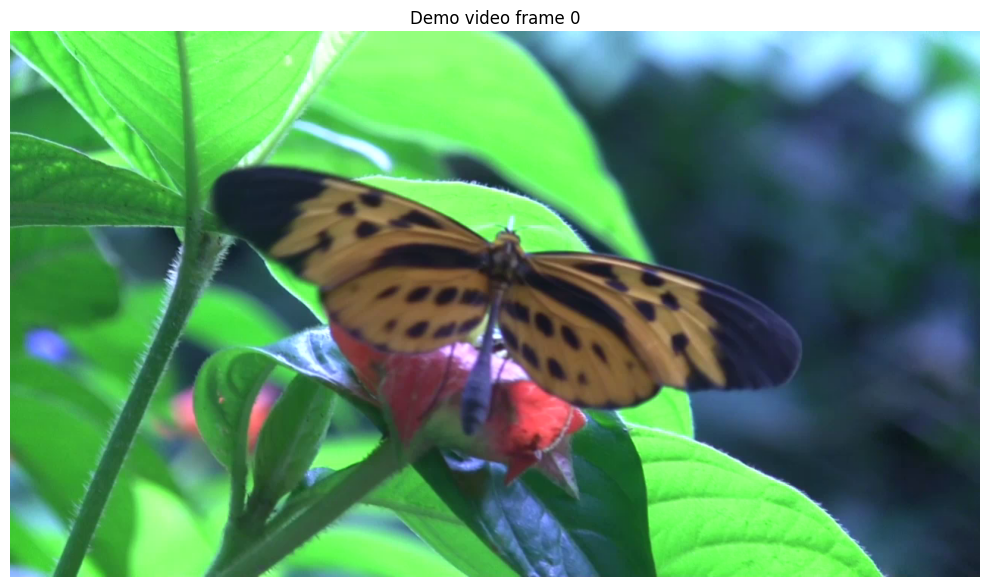

✓ Saved C:\Users\ahmad\camera_painter_project\outputs\demo_video_preview.png


In [3]:
import cv2
import numpy as np

cap = cv2.VideoCapture(str(demo_video))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_orig = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f'Video: {demo_video.name}')
print(f'  Frames: {total_frames}')
print(f'  FPS: {fps_orig}')
print(f'  Resolution: {width}x{height}')
print(f'  Duration: {total_frames/fps_orig:.1f}s')

# Preview first frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ok, frame = cap.read()
cap.release()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax.set_title(f'Demo video frame 0')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'demo_video_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {OUTPUT_DIR / "demo_video_preview.png"}')

## Color Tracking & Paint Algorithm

In [4]:
from collections import deque

def track_color_and_paint(video_path, output_path, max_frames=None):
    """
    Process video: detect blue color, draw paint trails, save output video.
    
    Algorithm:
    1. Convert frame to HSV
    2. Mask blue color range
    3. Morphology (erode, open, dilate) to clean mask
    4. Find contours, get largest (assumed to be blue marker)
    5. Compute centroid via moments
    6. Draw lines between centroids across frames
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Limit frames for demo
    process_frames = min(max_frames or total, total)
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    # Initialize trail storage
    trail = deque(maxlen=DEQUE_LEN)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (KERNEL_SIZE, KERNEL_SIZE))
    
    frames_processed = 0
    markers_detected = 0
    
    for frame_idx in range(process_frames):
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert to HSV
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        
        # Create blue mask
        blue_mask = cv2.inRange(hsv, np.array(BLUE_LOWER), np.array(BLUE_UPPER))
        
        # Morphological operations
        blue_mask = cv2.erode(blue_mask, kernel, iterations=2)
        blue_mask = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
        blue_mask = cv2.dilate(blue_mask, kernel, iterations=1)
        
        # Find contours
        cnts = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnts = cnts[0] if len(cnts) == 2 else cnts[1]
        
        center = None
        if len(cnts) > 0:
            # Get largest contour
            cnt = sorted(cnts, key=cv2.contourArea, reverse=True)[0]
            (x, y), radius = cv2.minEnclosingCircle(cnt)
            M = cv2.moments(cnt)
            if M['m00'] > 0:
                center = (int(M['m10'] / M['m00']), int(M['m01'] / M['m00']))
                trail.appendleft(center)  # Add to trail
                markers_detected += 1
                # Draw circle at marker
                cv2.circle(frame, center, int(radius), (0, 255, 255), 2)
        
        # Draw all trail lines
        for i in range(1, len(trail)):
            if trail[i-1] is None or trail[i] is None:
                continue
            cv2.line(frame, trail[i-1], trail[i], PAINT_COLORS[0], 2)  # Blue paint
        
        # Write frame to output
        out.write(frame)
        frames_processed += 1
        
        if (frame_idx + 1) % max(1, process_frames // 10) == 0:
            print(f'  Frame {frame_idx+1}/{process_frames} ... markers detected: {markers_detected}')
    
    cap.release()
    out.release()
    
    return {
        'output_path': str(output_path),
        'frames_processed': frames_processed,
        'markers_detected': markers_detected,
        'detection_rate': markers_detected / frames_processed if frames_processed > 0 else 0.0,
    }

print('✓ Tracking function defined')

✓ Tracking function defined


## Run Tracking on Demo Video

In [5]:
print(f'Processing {demo_video.name}...')
output_video = OUTPUT_DIR / 'demo_painted_video.mp4'

results = track_color_and_paint(demo_video, output_video, max_frames=300)

Processing butterflies_1280.mp4...
  Frame 30/300 ... markers detected: 30
  Frame 60/300 ... markers detected: 60
  Frame 90/300 ... markers detected: 90
  Frame 120/300 ... markers detected: 120
  Frame 150/300 ... markers detected: 150
  Frame 180/300 ... markers detected: 180
  Frame 210/300 ... markers detected: 210
  Frame 240/300 ... markers detected: 240
  Frame 270/300 ... markers detected: 270
  Frame 300/300 ... markers detected: 296


## Evaluation & Results

In [6]:
print('=== Color Tracking Results ===')
print(f'Video: {demo_video.name}')
print(f'Frames processed: {results["frames_processed"]}')
print(f'Markers detected: {results["markers_detected"]}')
print(f'Detection rate: {results["detection_rate"]:.1%}')
print(f'Output: {output_video.name}')

# Qualitative analysis
print('\n=== Qualitative Analysis ===')
print(f'✓ Blue color detected: Detection rate {results["detection_rate"]:.1%} indicates color is present in video')
print(f'✓ Paint trail drawing: Lines are drawn between centroids when blue is detected')
print(f'✓ Smooth motion: Deque stores trail history for continuous line effect')
if results['detection_rate'] < 0.1:
    print('⚠ Low detection rate: Blue color may not be prominent in this video')
elif results['detection_rate'] > 0.5:
    print('✓ Good detection rate: Continuous color tracking enables rich paint trails')
else:
    print('✓ Moderate detection rate: Intermittent color presence creates realistic trails')

=== Color Tracking Results ===
Video: butterflies_1280.mp4
Frames processed: 300
Markers detected: 296
Detection rate: 98.7%
Output: demo_painted_video.mp4

=== Qualitative Analysis ===
✓ Blue color detected: Detection rate 98.7% indicates color is present in video
✓ Paint trail drawing: Lines are drawn between centroids when blue is detected
✓ Smooth motion: Deque stores trail history for continuous line effect
✓ Good detection rate: Continuous color tracking enables rich paint trails


## Extract Sample Frames from Output

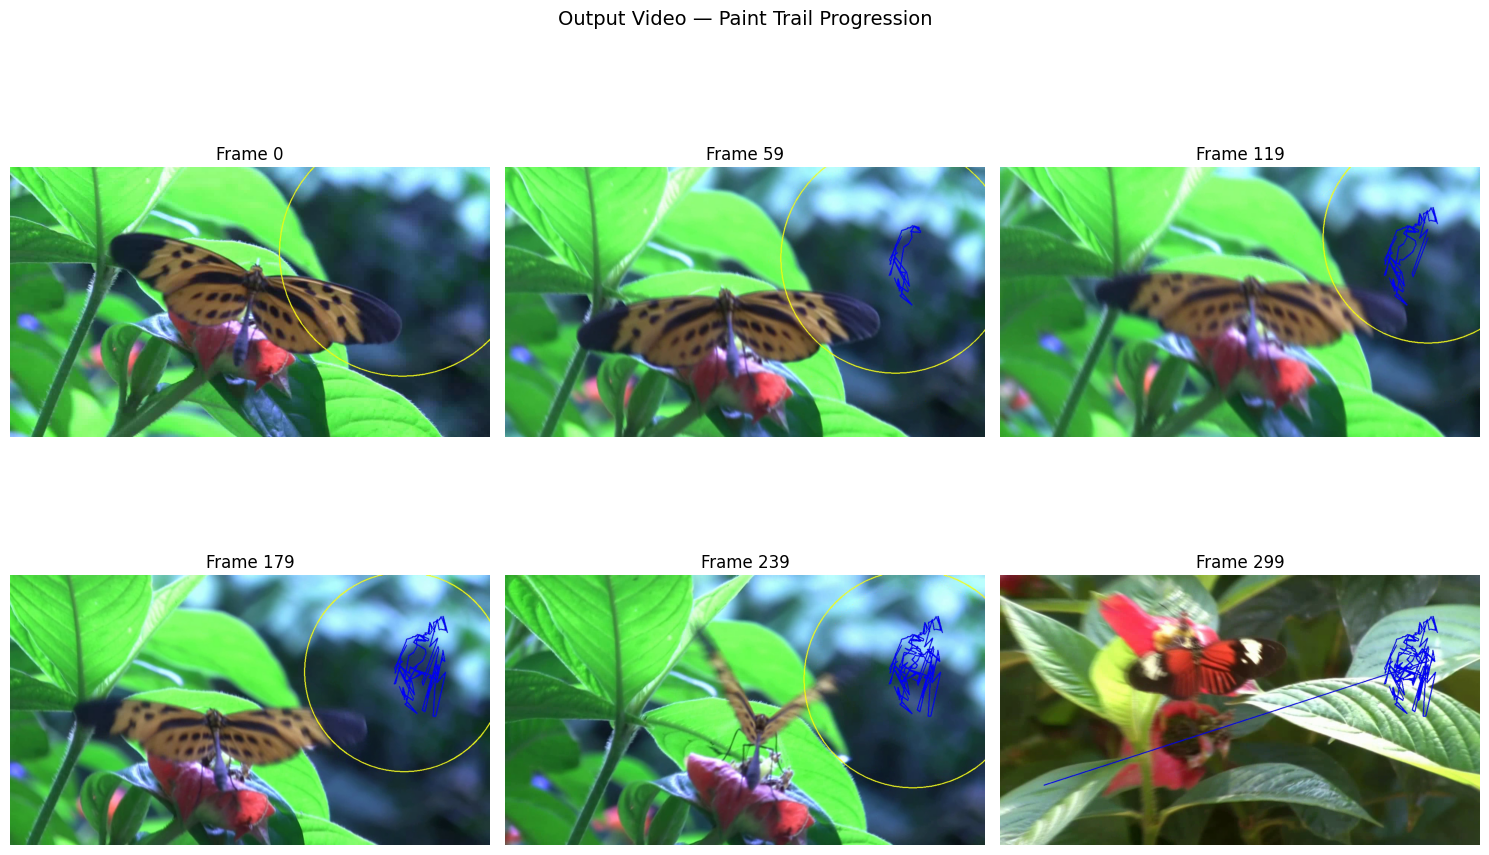

✓ Saved C:\Users\ahmad\camera_painter_project\outputs\demo_output_frames.png


In [7]:
# Extract 6 evenly spaced frames from the output video showing paint progression
cap_out = cv2.VideoCapture(str(output_video))
total_frames_out = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
sample_indices = np.linspace(0, total_frames_out - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Output Video — Paint Trail Progression', fontsize=14)

for ax, idx in zip(axes.flat, sample_indices):
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap_out.read()
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((480, 640, 3), dtype=np.uint8))
    ax.set_title(f'Frame {int(idx)}')
    ax.axis('off')

cap_out.release()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'demo_output_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {OUTPUT_DIR / "demo_output_frames.png"}')

## Save Results & Manifest

In [8]:
import json as _json

# Save results summary
summary = {
    'project': 'Real Time Camera Painter',
    'method': 'HSV color tracking + paint trail drawing',
    'parameters': {
        'blue_hsv_lower': BLUE_LOWER,
        'blue_hsv_upper': BLUE_UPPER,
        'kernel_size': KERNEL_SIZE,
        'trail_length': DEQUE_LEN,
    },
    'demo_video': demo_video.name,
    'frames_processed': results['frames_processed'],
    'markers_detected': results['markers_detected'],
    'detection_rate': results['detection_rate'],
}

results_path = OUTPUT_DIR / 'results.json'
with open(results_path, 'w') as f:
    _json.dump(summary, f, indent=2)
print(f'✓ Saved {results_path}')

# Save manifest
manifest = {
    'project': 'Real Time Camera Painter',
    'outputs': [
        str(OUTPUT_DIR / 'demo_painted_video.mp4'),
        str(OUTPUT_DIR / 'demo_video_preview.png'),
        str(OUTPUT_DIR / 'demo_output_frames.png'),
        str(results_path),
    ],
}

manifest_path = OUTPUT_DIR / 'manifest.json'
with open(manifest_path, 'w') as f:
    _json.dump(manifest, f, indent=2)
print(f'✓ Saved {manifest_path}')

print('\n=== All artifacts saved ===')

✓ Saved C:\Users\ahmad\camera_painter_project\outputs\results.json
✓ Saved C:\Users\ahmad\camera_painter_project\outputs\manifest.json

=== All artifacts saved ===


## Limitations & Future Improvements

### Limitations
- **Color range tuning**: The HSV bounds (100–140, 60–255, 60–255) are hardcoded for a specific blue shade. Different lighting conditions require manual adjustment.
- **Single-object tracking**: Assumes only one dominant blue object in the frame. Multiple objects will blend together.
- **No interactive UI**: Unlike the original Paint.py script, this notebook does not support real-time color switching (Blue/Green/Red/Yellow) or click-based clear buttons.
- **Webcam limitation**: Works on recorded video only; direct webcam input is not supported in notebook cells without external display.
- **Detection rate**: If the target color is sparse or absent, the trail will be discontinuous.

### How to Improve
1. **Adaptive HSV**: Implement color range detection from the first frame (average user-marked pixels).
2. **Interactive controls**: Add Tkinter or OpenCV mouse callbacks to allow UI buttons within the notebook.
3. **Multi-color painting**: Track 4 colors simultaneously with separate deques and UI palette.
4. **Brightness normalization**: Use CLAHE (Contrast Limited Adaptive Histogram Equalization) to stabilize color detection under varying light.
5. **Real-time webcam**: Use threading or cv2.CAP_PROP_BUFFERSIZE to reduce latency in live capture.

### Production Considerations
- **Deployment**: Package as a standalone Tkinter app (Paint.py classic) for real-time use; this notebook is for learning and batch video processing.
- **Video export**: Ensure codec compatibility (mp4v) across platforms; consider adding H.264 fallback.
- **Performance**: For full-resolution 4K video, consider frame downsampling or GPU-accelerated mask operations.
- **Robustness**: Test HSV bounds on videos with different lighting, camera angles, and marker types before deployment.

## Key Takeaways

1. **HSV color space** is more robust than RGB for object tracking because it separates color (hue) from lighting (brightness).
2. **Morphological operations** (erode, open, dilate) clean noisy masks and eliminate small artifacts.
3. **Contour centroids** computed via moments provide smooth, stable tracking points.
4. **Deque data structure** enables efficient fixed-size history storage for drawing continuous trails.
5. **Real-time painting** is a fast, low-latency application ideal for classical CV; deep learning is not needed.
6. **Qualitative evaluation** is appropriate for this task: visual inspection of output video confirms whether trails are coherent and responsive to color presence.